In [26]:
!git clone https://github.com/KaizokuOu56/movingMirror.git

Cloning into 'movingMirror'...
remote: Enumerating objects: 159, done.
remote: Counting objects: 100% (66/66), done.
remote: Compressing objects: 100% (51/51), done.
remote: Total 159 (delta 28), reused 42 (delta 12), pack-reused 93 (from 1)
Receiving objects: 100% (159/159), 174.44 MiB | 31.25 MiB/s, done.
Resolving deltas: 100% (56/56), done.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np

N = 200          # grid size
K = 10           # Fourier modes
num_samples = 50000
epochs = 30

In [3]:
t = np.linspace(0, 1, N, endpoint=False)

In [4]:
rng = np.random.default_rng(42)

Wr = rng.normal(size=(N, N))
Wi = rng.normal(size=(N, N))
alpha = 0.1
W = Wr + 1j * Wi
W = alpha * W

br = rng.normal(size=N)
bi = rng.normal(size=N)
b = br + 1j * bi
b = alpha * b

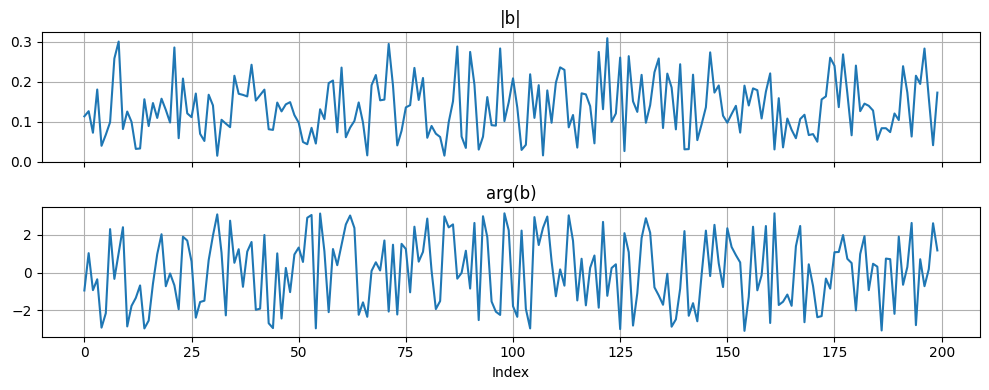

In [5]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 1, figsize=(10, 4), sharex=True)

axs[0].plot(np.abs(b))
axs[0].set_title("|b|")
axs[0].grid(True)

axs[1].plot(np.angle(b))
axs[1].set_title("arg(b)")
axs[1].grid(True)

plt.xlabel("Index")
plt.tight_layout()
plt.show()

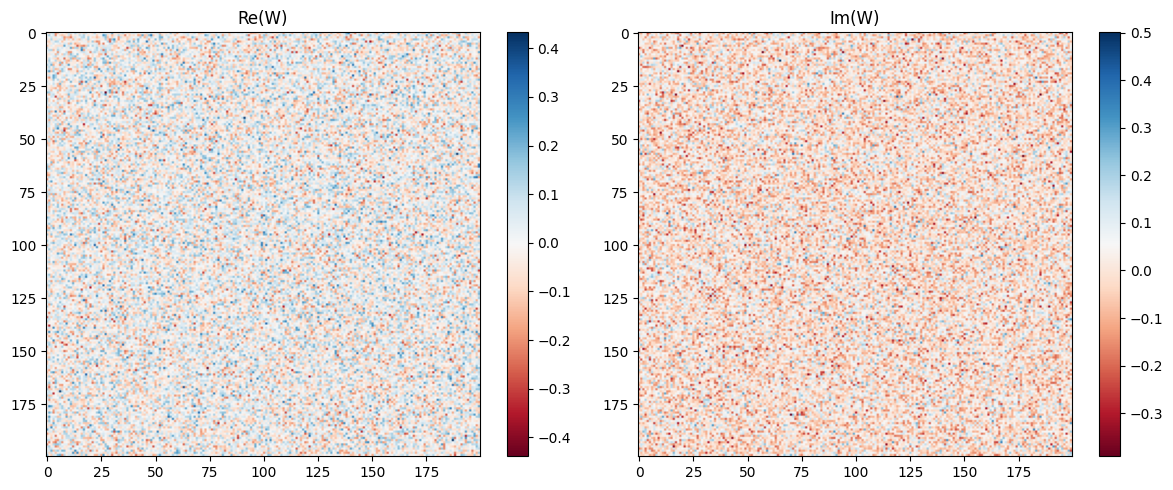

In [6]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(W.real, cmap="RdBu", aspect="auto")
plt.colorbar()
plt.title("Re(W)")

plt.subplot(1,2,2)
plt.imshow(W.imag, cmap="RdBu", aspect="auto")
plt.colorbar()
plt.title("Im(W)")

plt.tight_layout()
plt.show()

In [7]:
def sample_fourier_series(t, K):
    """
    Returns x ∈ ℂ^N
    """
    x = np.zeros_like(t, dtype=np.complex128)

    for k in range(-K, K + 1):
        a_k = np.random.uniform(-1,1)
        x += a_k * np.sin(2 * np.pi * k * t)

    return x

In [8]:
X = np.zeros((num_samples, N), dtype=np.complex128)
Y = np.zeros((num_samples, N), dtype=np.complex128)

for i in range(num_samples):
    x = sample_fourier_series(t, K)
    y = np.sin(W @ x + b)
    y = y / np.linalg.norm(y)

    X[i] = x
    Y[i] = y

    if(i % 1000 == 0):
        print(f"{i} / {num_samples} samples")
print("Done son")


0 / 50000 samples
1000 / 50000 samples
2000 / 50000 samples
3000 / 50000 samples
4000 / 50000 samples
5000 / 50000 samples
6000 / 50000 samples
7000 / 50000 samples
8000 / 50000 samples
9000 / 50000 samples
10000 / 50000 samples
11000 / 50000 samples
12000 / 50000 samples
13000 / 50000 samples
14000 / 50000 samples
15000 / 50000 samples
16000 / 50000 samples
17000 / 50000 samples
18000 / 50000 samples
19000 / 50000 samples
20000 / 50000 samples
21000 / 50000 samples
22000 / 50000 samples
23000 / 50000 samples
24000 / 50000 samples
25000 / 50000 samples
26000 / 50000 samples
27000 / 50000 samples
28000 / 50000 samples
29000 / 50000 samples
30000 / 50000 samples
31000 / 50000 samples
32000 / 50000 samples
33000 / 50000 samples
34000 / 50000 samples
35000 / 50000 samples
36000 / 50000 samples
37000 / 50000 samples
38000 / 50000 samples
39000 / 50000 samples
40000 / 50000 samples
41000 / 50000 samples
42000 / 50000 samples
43000 / 50000 samples
44000 / 50000 samples
45000 / 50000 samples
4

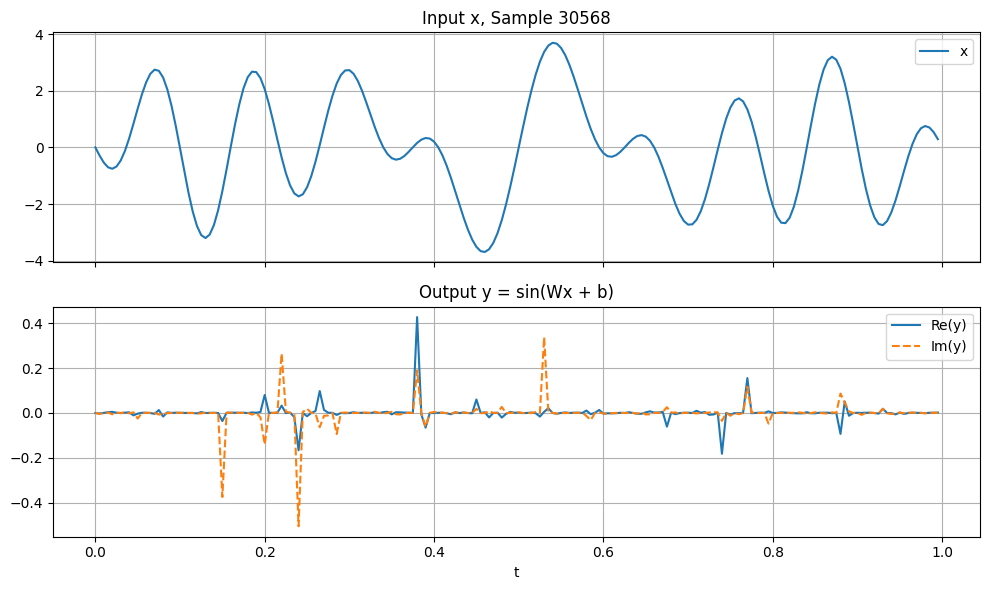

In [9]:
import matplotlib.pyplot as plt

i = np.random.randint(num_samples)  # random sample

t = np.linspace(0, 1, X.shape[1], endpoint=False)

fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Input x
axs[0].plot(t, X[i].real, label="x")
axs[0].set_title(f"Input x, Sample {i}")
axs[0].legend()
axs[0].grid(True)

# Output y
axs[1].plot(t, Y[i].real, label="Re(y)")
axs[1].plot(t, Y[i].imag, label="Im(y)", linestyle="--")
axs[1].set_title("Output y = sin(Wx + b)")
axs[1].legend()
axs[1].grid(True)

plt.xlabel("t")
plt.tight_layout()
plt.show()


In [10]:
import torch
from torch.utils.data import Dataset

class RealImagOperatorDataset(Dataset):
    def __init__(self, X, Y):
        self.x = torch.tensor(X.real, dtype=torch.float32)
        self.y_real = torch.tensor(Y.real, dtype=torch.float32)
        self.y_imag = torch.tensor(Y.imag, dtype=torch.float32)

    def __len__(self):
        return self.x.shape[0]

    def __getitem__(self, idx):
        x = self.x[idx][None, :]        # (1, 200)
        y_r = self.y_real[idx][None, :]
        y_i = self.y_imag[idx][None, :]
        return x, y_r, y_i

In [11]:
!pip install neuraloperator

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.6/248.6 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 116.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.3/59.3 kB 6.5 MB/s eta 0:00:00


In [12]:
from neuralop.models import FNO

def make_fno():
    return FNO(
        n_modes=(32, ),
        hidden_channels=64,
        in_channels=1,
        out_channels=1,
        n_layers=4
    )

In [13]:
model_real = make_fno()
model_imag = make_fno()

In [14]:
def fourier_loss(pred, target):
    """
    pred, target: (batch, 1, n_points)
    """
    pred_hat = torch.fft.rfft(pred, dim=-1)
    target_hat = torch.fft.rfft(target, dim=-1)

    return torch.mean(torch.abs(pred_hat - target_hat) ** 2)

In [ ]:
from torch.utils.data import DataLoader
import torch.nn.functional as F
from tqdm.auto import tqdm

dataset = RealImagOperatorDataset(X, Y)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

opt_real = torch.optim.Adam(model_real.parameters(), lr=1e-3)
opt_imag = torch.optim.Adam(model_imag.parameters(), lr=1e-3)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
model_real = model_real.to(device)
model_imag = model_imag.to(device)

model_real.train()
model_imag.train()

lambda_fourier = 0.05
losses = np.zeros(epochs)

for epoch in range(epochs):
    pbar = tqdm(loader, desc=f"Epoch {epoch}", leave=False)

    for x, y_r, y_i in pbar:
        x   = x.to(device)
        y_r = y_r.to(device)
        y_i = y_i.to(device)

        # --- real model ---
        pred_r = model_real(x)
        # loss_r = F.mse_loss(pred_r, y_r) + lambda_fourier * fourier_loss(pred_r, y_r)
        loss_r = F.mse_loss(pred_r, y_r)
        opt_real.zero_grad()
        loss_r.backward()
        opt_real.step()

        # --- imag model ---
        pred_i = model_imag(x)
        # loss_i = F.mse_loss(pred_i, y_i) + lambda_fourier * fourier_loss(pred_i, y_i)
        loss_i = F.mse_loss(pred_i, y_i)
        opt_imag.zero_grad()
        loss_i.backward()
        opt_imag.step()

        # live update
        pbar.set_postfix({
            "Re": f"{loss_r.item():.2e}",
            "Im": f"{loss_i.item():.2e}"
        })

        losses[epoch] += loss_r.item() + loss_i.item()

    losses[epoch] /= len(loader)

    print(f"Epoch {epoch} done | "
          f"Total Loss = {losses[epoch]:.3e}")

In [21]:
import os

save_dir = "/content/drive/MyDrive/movingMirror/experimental_data/trial3"
os.makedirs(save_dir, exist_ok=True)

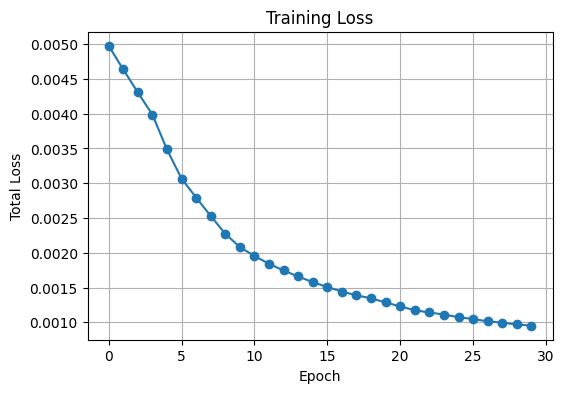

In [22]:
epochs_plotting = np.arange(len(losses))
plt.figure(figsize=(6,4))
plt.plot(epochs_plotting, losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Total Loss")
plt.title("Training Loss")
plt.grid(True)
save_path = os.path.join(save_dir, "training_loss.png")
fig.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

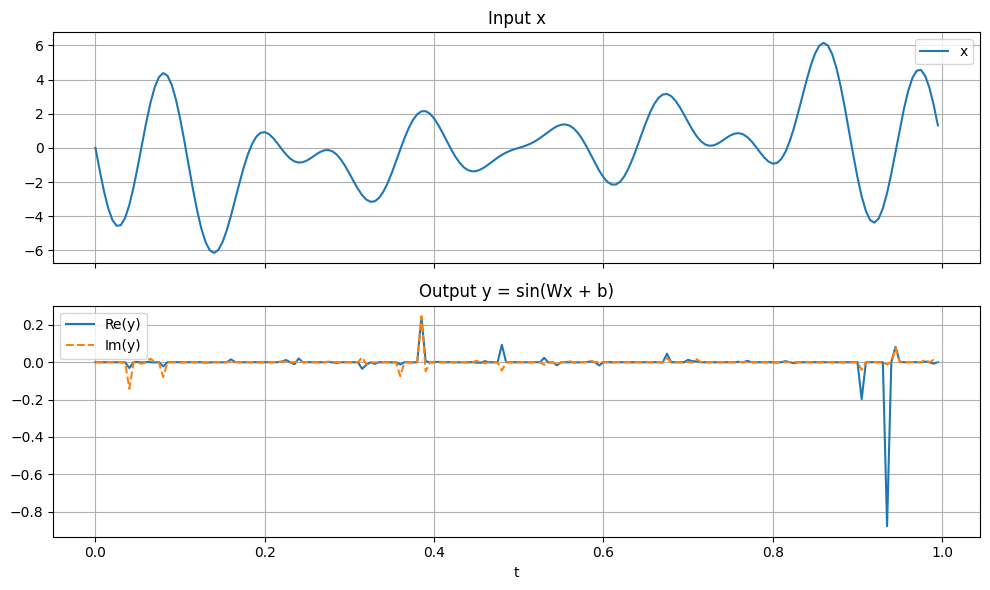

In [23]:
i = np.random.randint(len(X))  # random sample

t = np.linspace(0, 1, X.shape[1], endpoint=False)

fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Input x
axs[0].plot(t, X[i].real, label="x")
axs[0].set_title("Input x")
axs[0].legend()
axs[0].grid(True)

# Output y
axs[1].plot(t, Y[i].real, label="Re(y)")
axs[1].plot(t, Y[i].imag, label="Im(y)", linestyle="--")
axs[1].set_title("Output y = sin(Wx + b)")
axs[1].legend()
axs[1].grid(True)

plt.xlabel("t")
plt.tight_layout()
plt.show()

save_path = os.path.join(save_dir, "sample.png")
fig.savefig(save_path, dpi=300, bbox_inches="tight")

7507


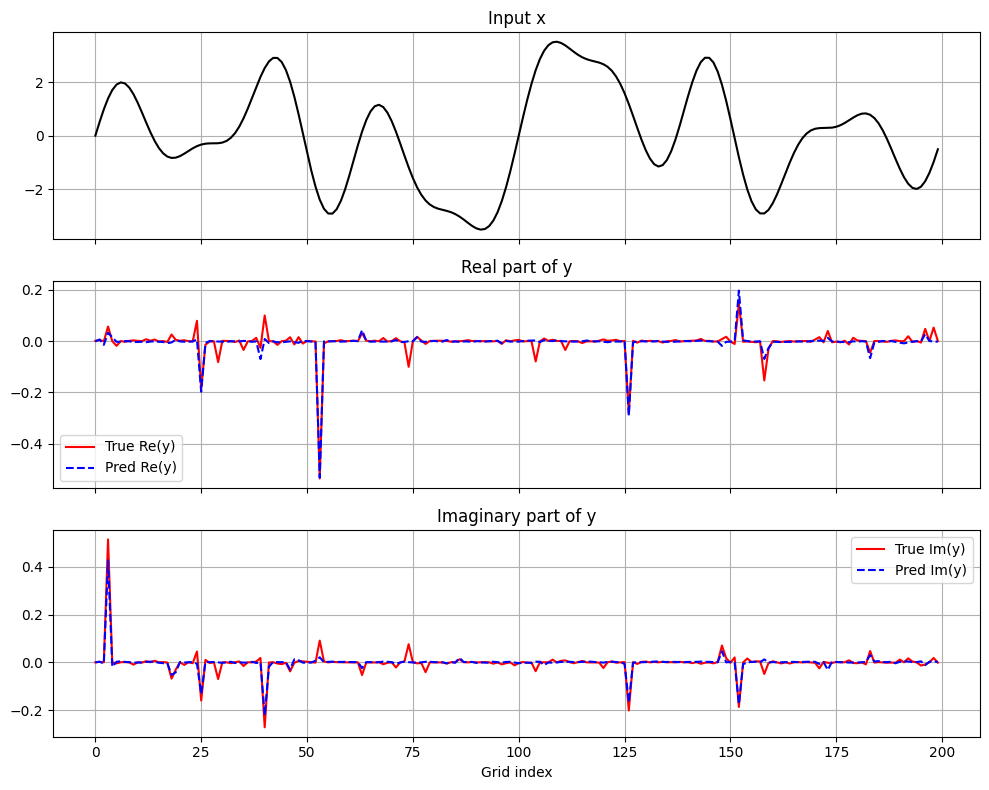

In [25]:
i = np.random.randint(len(X))
print(i)

# input x (real)
x_np = X[i].real              # (200,)

# true y
y_true = Y[i]                 # complex, (200,)
y_true_r = y_true.real
y_true_i = y_true.imag

device = next(model_real.parameters()).device

x_torch = torch.tensor(x_np, dtype=torch.float32, device=device)[None, None, :]
# shape: (1, 1, 200)

model_real.eval()
model_imag.eval()

with torch.no_grad():
    y_pred_r = model_real(x_torch)[0, 0].cpu().numpy()
    y_pred_i = model_imag(x_torch)[0, 0].cpu().numpy()

t = np.arange(len(x_np))  # or your physical grid

fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# --- x ---
axs[0].plot(t, x_np, color="black")
axs[0].set_title("Input x")
axs[0].grid(True)

# --- y real ---
axs[1].plot(t, y_true_r, label="True Re(y)", color="red")
axs[1].plot(t, y_pred_r, label="Pred Re(y)", color="blue", linestyle="--")
axs[1].set_title("Real part of y")
axs[1].legend()
axs[1].grid(True)

# --- y imag ---
axs[2].plot(t, y_true_i, label="True Im(y)", color="red")
axs[2].plot(t, y_pred_i, label="Pred Im(y)", color="blue", linestyle="--")
axs[2].set_title("Imaginary part of y")
axs[2].legend()
axs[2].grid(True)

plt.xlabel("Grid index")
plt.tight_layout()
plt.show()

save_path = os.path.join(save_dir, "prediction.png")
fig.savefig(save_path, dpi=300, bbox_inches="tight")

In [27]:
%cd movingMirror

/content/movingMirror
